In [23]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [9]:
# sns.get_dataset_names()
titanic=sns.load_dataset("titanic")
titanic.head()
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
features=["age", "embarked", "pclass", "sex", "fare"]
target=["survived"]

In [16]:
#handle missing values
from sklearn.impute import SimpleImputer

imp_mean=SimpleImputer(strategy="median")
titanic[["age"]]=imp_mean.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [20]:
#encoding: LabelEncoding

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [21]:
X=titanic[features]
y=titanic[target]

In [22]:
#train test split

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
#decision tree: no pruning

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred=model.predict(X_test)

print("accuracy_score:", accuracy_score(y_test, y_pred))

accuracy_score: 0.770949720670391


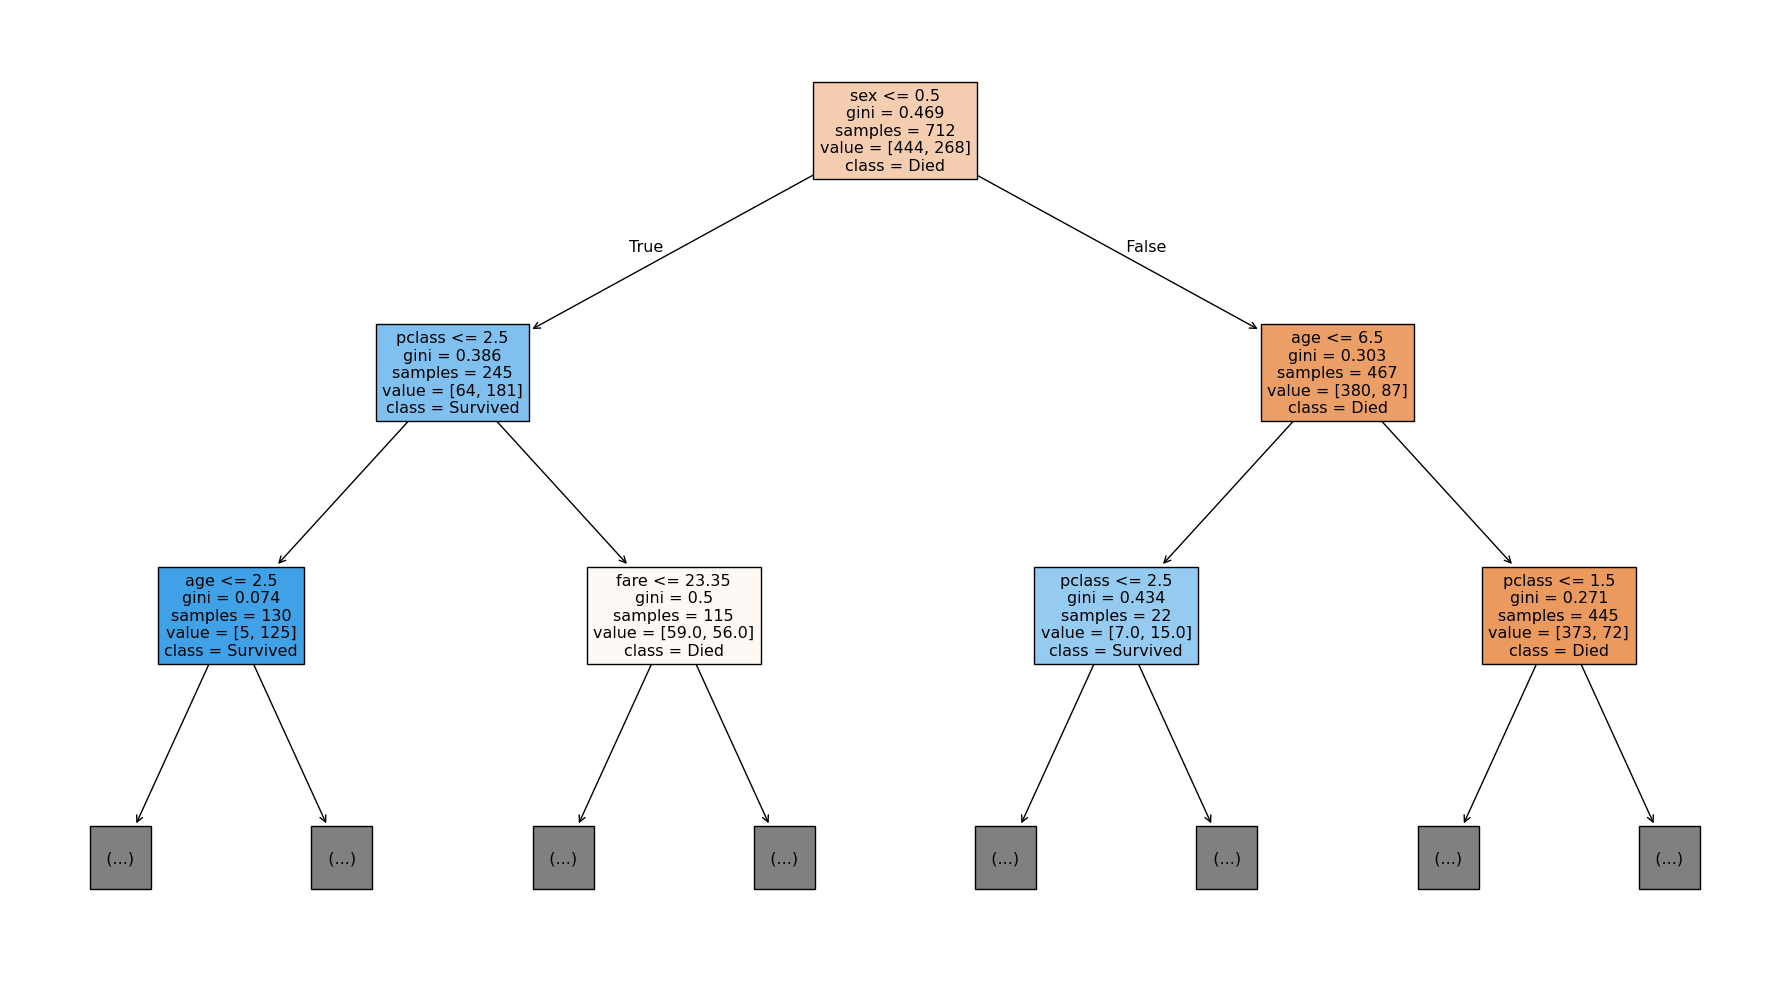

In [33]:
#plot tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

# # decision tree with pre-pruning

In [36]:

max_depths=[2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    acc=model.score(X_test, y_test)
    print(f"max_depth: {depth}, accuracy: {acc}")


max_depth: 2, accuracy: 0.7653631284916201
max_depth: 3, accuracy: 0.7988826815642458
max_depth: 4, accuracy: 0.7988826815642458
max_depth: 5, accuracy: 0.7988826815642458
max_depth: 6, accuracy: 0.7988826815642458
max_depth: 7, accuracy: 0.8044692737430168
max_depth: 8, accuracy: 0.7988826815642458
max_depth: 9, accuracy: 0.7988826815642458
max_depth: 10, accuracy: 0.7877094972067039


In [38]:
min_sample_splits=[5, 10, 15, 20, 25, 30]

for split in min_sample_splits:
    model=DecisionTreeClassifier(min_samples_split=split)
    model.fit(X_train, y_train)
    acc=model.score(X_test, y_test)
    print(f"max_depth: {depth}, accuracy: {acc}")

max_depth: 10, accuracy: 0.7877094972067039
max_depth: 10, accuracy: 0.8268156424581006
max_depth: 10, accuracy: 0.8324022346368715
max_depth: 10, accuracy: 0.8379888268156425
max_depth: 10, accuracy: 0.8268156424581006
max_depth: 10, accuracy: 0.8100558659217877


# # decision tree with post-pruning

In [40]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [41]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas=path.ccp_alphas

In [42]:
ccp_alphas

array([0.00000000e+00, 0.00000000e+00, 3.12109863e-05, 6.68806849e-05,
       8.91742465e-05, 1.63857678e-04, 2.00642055e-04, 2.34082397e-04,
       2.34082397e-04, 2.34082397e-04, 3.51123596e-04, 4.68164794e-04,
       4.68164794e-04, 4.68164794e-04, 4.68164794e-04, 5.35045479e-04,
       5.61797753e-04, 6.24219725e-04, 6.24219725e-04, 6.67991230e-04,
       7.02247191e-04, 8.19288390e-04, 8.19288390e-04, 8.42696629e-04,
       8.42696629e-04, 8.94231048e-04, 9.24769963e-04, 9.36329588e-04,
       9.36329588e-04, 9.36329588e-04, 1.01064146e-03, 1.02996255e-03,
       1.07400895e-03, 1.07953294e-03, 1.08038029e-03, 1.11865144e-03,
       1.12359551e-03, 1.12359551e-03, 1.17041199e-03, 1.17041199e-03,
       1.18841832e-03, 1.22566125e-03, 1.22893258e-03, 1.22893258e-03,
       1.24843945e-03, 1.26404494e-03, 1.27565833e-03, 1.30996111e-03,
       1.33761370e-03, 1.37044603e-03, 1.46301498e-03, 1.51229549e-03,
       1.56737310e-03, 1.60434338e-03, 1.64211936e-03, 1.66892062e-03,
      

In [55]:
#train model on all alphas

tree=[]

for alpha in ccp_alphas:
    model=DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    acc=model.score(X_test, y_test)

    tree.append((model, alpha))


In [56]:
best_acc=0
best_alpha=0

for model, alpha in tree:
    curr_acc=model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc=curr_acc
        best_alpha=alpha

In [57]:
best_acc

0.8435754189944135

In [60]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.001642119357497887),
                       random_state=42)

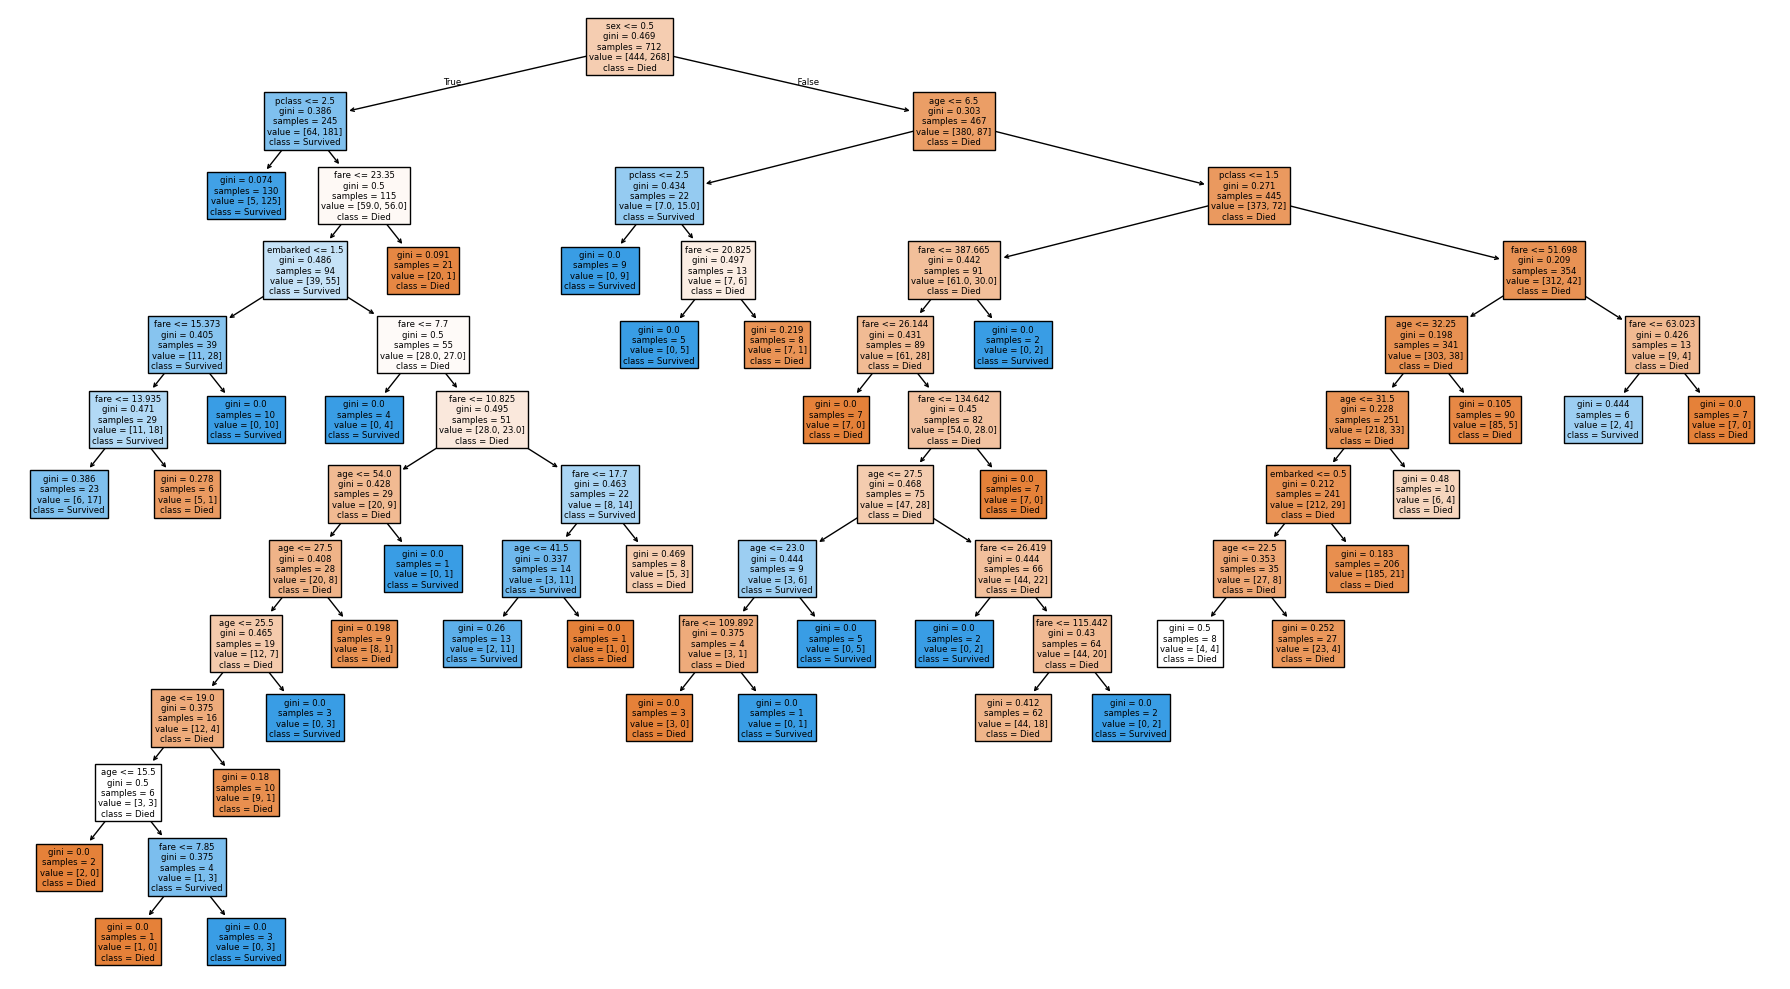

In [61]:
plt.figure(figsize=(18, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)

plt.tight_layout()
plt.show()